In [1]:
# 라이브러리 설치 확인

import chromadb
# chromadb : VectorDB (벡터 저장 & 유사도 검색)
import neo4j
# neo4j : GraphDB 드라이버 (Neo4j 서버와 통신)
import sentence_transformers
# sentence_transformers : 텍스트를 숫자 벡터(임베딩)로 변환하는 모델
print(chromadb.__version__, neo4j.__version__, sentence_transformers.__version__)

1.5.9 6.2.0 5.5.1


In [2]:
# ================================================================
# ChromaDB 클라이언트 생성
# ================================================================

# chromadb를 사용하려면 먼저 "클라이언트"를 만들어야 함
# 클라이언트 = VectorDB 서버에 접속하는 연결 객체
import chromadb
client = chromadb.Client()
# chromadb.Client() -> 인메모리(RAM) 모드로 실행

# 서버 설치 없이 바로 사용 가능
# 단점 : 프로그램 종료 시 데이터 사라짐 (임시 저장)

# chromadb.PersistentClient(path='./outputs')
# 이 방식으로 디스크에 영구 저장 (지금은 사용 X)

# heartbeat() : DB 서버가 살아있는지 확인하는 핑(ping) 테스트
# 숫자(나노초 타임스탬프)가 출력되면 정상
client.heartbeat()

1779846955672852800

In [3]:
# ================================================================
# STEP 2. 컬렉션 생성 & 데이터 추가
# ================================================================

# 컬렉션 (Collection)
# RDBMS(관계형DB)의 "테이블"과 같은 개념
# 여러 개의 벡터(문서)를 하나의 묶음으로 관리하는 단위

collection = client.get_or_create_collection(
    name='korean_food',     # 컬렉션 이름 (테이블 이름)
    metadata={'hnsw:space': 'cosine'}
    # hnsw:space : 유사도를 측정할 때 쓸 거리 방식 지정
    # 'cosine' : 코사인 유사도 사용 (텍스트 검색에 가장 많이 사용) 
)

print(f'컬렉션 이름 : {collection.name}')
print(f'현재 문서 수 : {collection.count()}')


컬렉션 이름 : korean_food
현재 문서 수 : 0


In [4]:
# ----------------------------------------------------------------
# 저장할 데이터 준비
# ----------------------------------------------------------------

# documents : 실제로 저장할 텍스트 문장들
# VectorDB는 이 문장들을 숫자 벡터로 변환해서 저장
documents = [
    "김치찌개는 돼지고기와 김치를 넣고 끓인 한국의 대표적인 찌개 요리입니다.",
    "불고기는 간장 양념에 재운 소고기를 구워 먹는 한국 전통 요리입니다.",
    "비빔밥은 밥 위에 다양한 나물과 고추장을 넣고 비벼 먹는 음식입니다.",
    "된장찌개는 된장을 풀어 두부, 감자, 호박 등을 넣고 끓인 찌개입니다.",
    "삼겹살은 돼지 뱃살을 구워 쌈 채소에 싸서 먹는 인기 있는 요리입니다.",
    "떡볶이는 떡과 어묵을 고추장 양념에 볶아 만든 한국의 길거리 음식입니다.",
    "냉면은 메밀 면을 차가운 육수에 말아 먹는 여름철 별미입니다.",
    "잡채는 당면에 다양한 채소와 고기를 볶아 만든 명절 음식입니다.",
    "갈비탕은 소갈비를 오랫동안 끓여 만든 깊은 맛의 탕 요리입니다.",
    "순두부찌개는 부드러운 순두부에 해물이나 고기를 넣어 끓인 매운 찌개입니다.",
]

# metadatas : 각 문서에 붙이는 부가 정보 (태그 같은 것)
# 나중에 "찌개만 검색해줘", "매운 것만 빼줘" 같은 필터링에 활용
# documents 리스트와 순서가 반드시 1:1로 일치해야 함
metadatas = [
    {"category": "찌개", "main_ingredient": "돼지고기", "spicy": True},   # 김치찌개
    {"category": "구이", "main_ingredient": "소고기",   "spicy": False},  # 불고기
    {"category": "밥",   "main_ingredient": "채소",     "spicy": True},   # 비빔밥
    {"category": "찌개", "main_ingredient": "된장",     "spicy": False},  # 된장찌개
    {"category": "구이", "main_ingredient": "돼지고기", "spicy": False},  # 삼겹살
    {"category": "분식", "main_ingredient": "떡",       "spicy": True},   # 떡볶이
    {"category": "면",   "main_ingredient": "메밀",     "spicy": False},  # 냉면
    {"category": "볶음", "main_ingredient": "당면",     "spicy": False},  # 잡채
    {"category": "탕",   "main_ingredient": "소고기",   "spicy": False},  # 갈비탕
    {"category": "찌개", "main_ingredient": "순두부",   "spicy": True},   # 순두부찌개
]

# ids : 각 문서의 고유 식별자 (primary key 같은 것)
# f'food_{i:03d}' -> i를 3자리 숫자로 표현
ids = [f'food_{i:03d}' for i in range(len(documents))]
print(f'ids = {ids}')

# ----------------------------------------------------------------
# 컬렉션에 데이터 추가
# ----------------------------------------------------------------

# collection.add() 호출 시 내부에서 일어나는 일:
# 1. documents의 각 문장을 임베딩 모델이 숫자 벡터로 변환
# 2. 변환된 벡터 + 원문 + 메타데이터 + id를 함께 저장
collection.add(
    documents=documents,    # 텍스트 문장 리스트
    metadatas=metadatas,    # 메타데이터 리스트 (documents와 순서 동일)
    ids=ids                 # 고유 id 리스트 (documents와 순서 동일)
)

"""{
    "id": "doc1",
    "document": "Apple is a fruit",
    "embedding": [0.12, -0.44, 0.91, ...],
    "metadata": {
        "category": "food"
    } 이런식으로 collection에 저장됨"""

print(f'{collection.count()}개 문서 추가 완료')

# 어떤 문서 들어갔는지 앞 30글자만 잘라서 출력
for doc_id, doc in zip(ids, documents):
    # zip(ids, documents) -> ids와 documents를 묶어서 동시에 순회
    print(f' {doc_id} : {doc[:30]}...')

ids = ['food_000', 'food_001', 'food_002', 'food_003', 'food_004', 'food_005', 'food_006', 'food_007', 'food_008', 'food_009']
10개 문서 추가 완료
 food_000 : 김치찌개는 돼지고기와 김치를 넣고 끓인 한국의 대표적인...
 food_001 : 불고기는 간장 양념에 재운 소고기를 구워 먹는 한국 전...
 food_002 : 비빔밥은 밥 위에 다양한 나물과 고추장을 넣고 비벼 먹...
 food_003 : 된장찌개는 된장을 풀어 두부, 감자, 호박 등을 넣고 ...
 food_004 : 삼겹살은 돼지 뱃살을 구워 쌈 채소에 싸서 먹는 인기 ...
 food_005 : 떡볶이는 떡과 어묵을 고추장 양념에 볶아 만든 한국의 ...
 food_006 : 냉면은 메밀 면을 차가운 육수에 말아 먹는 여름철 별미...
 food_007 : 잡채는 당면에 다양한 채소와 고기를 볶아 만든 명절 음...
 food_008 : 갈비탕은 소갈비를 오랫동안 끓여 만든 깊은 맛의 탕 요...
 food_009 : 순두부찌개는 부드러운 순두부에 해물이나 고기를 넣어 끓...


In [5]:
# ================================================================
# STEP 3. 유사도 검색 & 메타데이터 필터링
# ================================================================

# ----------------------------------------------------------------
# 기본 유사도 검색
# ----------------------------------------------------------------
# 검색할 질문 텍스트
query = '매운 국물 요리가 먹고 싶어요'

# collection.query() : 질문과 의미적으로 가장 비슷한 문서를 찾아줌
# 내부 동작 순서
# 1. query 텍스트를 벡터로 변환
# 2. 저장된 모든 문서 벡터와 코사인 거리 계산
# 3. 거리가 가까운(=의미가 비슷한) 순서로 정렬
# 4. 상위 n_results 개 반환
results = collection.query(
    query_texts=[query],    # 검색어. 리스트로 감싸야 함(여러 개 동시 검색 가능한 구조)
    n_results=5             # 상위 몇 개를 가져올지 (top-5)
)

# results의 구조:
# results['documents'][0] -> 검색된 문서 텍스트 리스트
# results['metadatas'][0] -> 검색된 문서 메타데이터 리스트
# results['distances'][0] -> 검색된 문서와의 코사인 거리 리스트
# [0]을 붙이는 이유 : query_texts에 여러 개를 넣을 수 있어서 결과도 2중 리스트 구조로 반환

for doc, meta, dist in zip(
    results['documents'][0],
    results['metadatas'][0],
    results['distances'][0]
):
    # 코사인 거리 -> 유사도 변환
    # ChromaDB는 거리(distance)를 반환
    # 거리 = 0 : 완전히 같은 문서, 거리 =1 : 전현 다른 문서
    # 유사도 = 1 - 거리 (유사도가 1에 가까울수록 비슷한 문서)
    similarity = 1 - dist
    print(similarity, doc, meta, dist)

0.8424747586250305 떡볶이는 떡과 어묵을 고추장 양념에 볶아 만든 한국의 길거리 음식입니다. {'category': '분식', 'main_ingredient': '떡', 'spicy': True} 0.15752524137496948
0.809877336025238 순두부찌개는 부드러운 순두부에 해물이나 고기를 넣어 끓인 매운 찌개입니다. {'main_ingredient': '순두부', 'category': '찌개', 'spicy': True} 0.19012266397476196
0.7872368097305298 김치찌개는 돼지고기와 김치를 넣고 끓인 한국의 대표적인 찌개 요리입니다. {'category': '찌개', 'spicy': True, 'main_ingredient': '돼지고기'} 0.21276319026947021
0.7770899534225464 냉면은 메밀 면을 차가운 육수에 말아 먹는 여름철 별미입니다. {'spicy': False, 'main_ingredient': '메밀', 'category': '면'} 0.2229100465774536
0.7485682368278503 잡채는 당면에 다양한 채소와 고기를 볶아 만든 명절 음식입니다. {'main_ingredient': '당면', 'category': '볶음', 'spicy': False} 0.25143176317214966


In [6]:
# ----------------------------------------------------------------
# 여러 질문을 한꺼번에 검색
# ----------------------------------------------------------------
queries = [
    "고기를 구워서 먹는 음식",
    "시원한 여름 음식 추천해주세요",
    "명절에 먹는 전통 음식",
]

# 각 질문에 대해서 top-3 문서를 출력
for query in queries:
    results = collection.query(
        query_texts = [query],
        n_results=3
    )
    print(f'\n질문 : {query}')
    for doc, meta, dist in zip(
        results['documents'][0],
        results['metadatas'][0],
        results['distances'][0]
    ):
        similarity = 1 -dist
        print(f'유사도({similarity:.4f}) 문서:{doc[:15]}..., 메타:{meta}')


질문 : 고기를 구워서 먹는 음식
유사도(0.7897) 문서:불고기는 간장 양념에 재운 ..., 메타:{'main_ingredient': '소고기', 'spicy': False, 'category': '구이'}
유사도(0.7736) 문서:떡볶이는 떡과 어묵을 고추장..., 메타:{'main_ingredient': '떡', 'spicy': True, 'category': '분식'}
유사도(0.7421) 문서:비빔밥은 밥 위에 다양한 나..., 메타:{'main_ingredient': '채소', 'spicy': True, 'category': '밥'}

질문 : 시원한 여름 음식 추천해주세요
유사도(0.7805) 문서:비빔밥은 밥 위에 다양한 나..., 메타:{'main_ingredient': '채소', 'category': '밥', 'spicy': True}
유사도(0.7060) 문서:냉면은 메밀 면을 차가운 육..., 메타:{'main_ingredient': '메밀', 'spicy': False, 'category': '면'}
유사도(0.6691) 문서:김치찌개는 돼지고기와 김치를..., 메타:{'main_ingredient': '돼지고기', 'spicy': True, 'category': '찌개'}

질문 : 명절에 먹는 전통 음식
유사도(0.7733) 문서:비빔밥은 밥 위에 다양한 나..., 메타:{'spicy': True, 'category': '밥', 'main_ingredient': '채소'}
유사도(0.7512) 문서:냉면은 메밀 면을 차가운 육..., 메타:{'category': '면', 'main_ingredient': '메밀', 'spicy': False}
유사도(0.7327) 문서:떡볶이는 떡과 어묵을 고추장..., 메타:{'main_ingredient': '떡', 'spicy': True, 'category': '분식'}


In [7]:
# ================================================================
# 메타데이터 필터링
# ================================================================

# 메타데이터 필터링 = 벡터 유사도 검색 + 조건 필터를 동시에 사용
# ex> "국물 요리 중에서 매운 것만 찾아줘"
# => 유사도 검색으로 국물 요릴 찾되, spicy=True 인 것만 반환

# ----------------------------------------------------------------
# 단순 필터: 매운 음식(spicy=True)만 검색
# ---------------------------------------------------------------
results = collection.query(
    query_texts=['따뜻한 국물 요리'],
    n_results=3,
    where={'spicy': True}   # 메타데이터 필터
    # where 조건에 맞지 않는 문서는 유사도 계산에서 아예 제외
    # 즉, spicy=True인 문서들 중에서만 유사도 순위를 매김
)
for doc, meta, dist in zip(
    results['documents'][0],
    results['metadatas'][0],
    results['distances'][0]
):
    similarity = 1 - dist
    print(f'유사도({similarity:.4f}) 문서:{doc[:15]}..., 메타:{meta}')

유사도(0.7249) 문서:김치찌개는 돼지고기와 김치를..., 메타:{'category': '찌개', 'main_ingredient': '돼지고기', 'spicy': True}
유사도(0.6877) 문서:순두부찌개는 부드러운 순두부..., 메타:{'spicy': True, 'category': '찌개', 'main_ingredient': '순두부'}
유사도(0.6662) 문서:떡볶이는 떡과 어묵을 고추장..., 메타:{'spicy': True, 'main_ingredient': '떡', 'category': '분식'}


In [8]:
# ----------------------------------------------------------------
# 복합 필터: AND 조건
# 소고기 또는 돼지고기를 사용하고 + 맵지 않은 음식
# ----------------------------------------------------------------
# ChromaDB 필터 연산자 정리:
#   $eq  : 같다          {'category': {'$eq': '찌개'}}
#   $in  : 목록 중 하나  {'category': {'$in': ['찌개', '탕']}}
#   $and : 두 조건 모두  {'$and': [{조건1}, {조건2}]}
#   $or  : 둘 중 하나    {'$or':  [{조건1}, {조건2}]}

results = collection.query(
    query_texts=["고기종류의 음식"],
    n_results=3,
    where={
        "$and": [
            # 조건 1: main_ingredient가 소고기 또는 돼지고기인 것
            {'main_ingredient': {"$in": ["소고기", "돼지고기"]}},
            # 조건 2: spicy가 False인 것 (맵지 않은 것)
            {'spicy': False}
        ]
    }
)

for doc, meta, dist in zip(
    results['documents'][0],
    results['metadatas'][0],
    results['distances'][0]
):
    similarity = 1 - dist
    print(f'유사도({similarity:.4f}) 문서:{doc[:15]}..., 메타:{meta}')

유사도(0.4934) 문서:불고기는 간장 양념에 재운 ..., 메타:{'spicy': False, 'category': '구이', 'main_ingredient': '소고기'}
유사도(0.4786) 문서:갈비탕은 소갈비를 오랫동안 ..., 메타:{'main_ingredient': '소고기', 'spicy': False, 'category': '탕'}
유사도(0.3948) 문서:삼겹살은 돼지 뱃살을 구워 ..., 메타:{'spicy': False, 'main_ingredient': '돼지고기', 'category': '구이'}


In [11]:
# ================================================================
# STEP 4. 커스텀 임베딩 모델 & CRUD
# ================================================================
# 커스텀 임베딩 모델
# ChromaDB 기본 임베딩 모델은 영어 위주라 한국어 성능이 낮음
# Sentence-Transformer의 한국어 특화 모델로 교체하면 성능 향상
# 모델명 : 'jhgan/ko-sroberta-multitask'
# - 한국어 문장을 의미적으로 잘 구분하도록 학습된 모델
# - 한국어 유사도 검색에서 기본 모델보다 훨씬 정확

# embedding_functions 는 ChromaDB에서 임베딩 모델을 교체할 때 사용
from chromadb.utils import embedding_functions

# SentenceTransformerEmbeddingFunction 
# : Sentence-Transformer 모델을 ChromaDB에서 바로 쓸 수 있도록 감싸주는 래퍼(wrapper)클래스
st_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name='jhgan/ko-sroberta-multitask'
    # 처음 실행 시 모델 파일을 인터넷에서 자동 다운로드 
    # 두 번째 실행부터는 캐시에서 바로 로드
)

# ----------------------------------------------------------------
# 커스텀 임베딩 모델용 컬렉션 새로 생성
# ----------------------------------------------------------------
# 이미 같은 이름의 컬렛견이 있으면 오류 -> 먼저 삭제
# (실수로 중복 실행했을 때를 대비)
try:
    client.delete_collection("korean_foods_custom")
except Exception as e:
    print(e)

# 새 컬렉션 생성 - embedding_function을 직접 지정
collection_custom = client.get_or_create_collection(
    name='korean_foods_custom',
    embedding_function = st_ef,
    metadata={'hnsw:space': "cosine"}
)

# 만든 documents, metadatas를 그대로 사용
# ids 만 'custom_000' 형식으로 새로 지정
collection_custom.add(
    documents=documents,
    metadatas = metadatas,
    ids = [f'custom_{i:03d}' for i in range(len(documents))]
)

Collection [korean_foods_custom] does not exist


In [12]:
# ----------------------------------------------------------------
# 기본 임베딩 vs 커스텀 임베딩 비교
# ----------------------------------------------------------------
# 같은 질문으로 두 컬렉션에 각각 검색해서 결과를 비교
test_query = '뜨끈한 국물이 있는 겨울 음식'

# r1: 기본 임베딩
r1 = collection.query(
    query_texts=[test_query],
    n_results=3
)

# r2: 커스텀 임베딩 + 메타데이터 필터
r2 = collection_custom.query(
    query_texts=[test_query],
    n_results=3,
    where={
        'category': {"$in": ["찌개", "탕"]}
    }
)

# 결과 출력 함수
def showResult(results):
    for doc, meta, dist in zip(
        results['documents'][0],
        results['metadatas'][0],
        results['distances'][0]
    ):
        similarity = 1 -dist
        print(f'유사도({similarity:.4f}) 문서:{doc[:15]}..., 메타:{meta}')

print('=== 기본 임베딩 결과 ===')
showResult(r1)
print('\n')
print('=== 커스텀 임베딩 결과 (찌개/탕 필터) ===')
showResult(r2)

=== 기본 임베딩 결과 ===
유사도(0.7688) 문서:떡볶이는 떡과 어묵을 고추장..., 메타:{'main_ingredient': '떡', 'spicy': True, 'category': '분식'}
유사도(0.7429) 문서:김치찌개는 돼지고기와 김치를..., 메타:{'category': '찌개', 'main_ingredient': '돼지고기', 'spicy': True}
유사도(0.6985) 문서:냉면은 메밀 면을 차가운 육..., 메타:{'main_ingredient': '메밀', 'category': '면', 'spicy': False}


=== 커스텀 임베딩 결과 (찌개/탕 필터) ===
유사도(0.4623) 문서:순두부찌개는 부드러운 순두부..., 메타:{'category': '찌개', 'main_ingredient': '순두부', 'spicy': True}
유사도(0.4315) 문서:김치찌개는 돼지고기와 김치를..., 메타:{'main_ingredient': '돼지고기', 'spicy': True, 'category': '찌개'}
유사도(0.3759) 문서:된장찌개는 된장을 풀어 두부..., 메타:{'spicy': False, 'category': '찌개', 'main_ingredient': '된장'}


In [ ]:
# STEP 1 : ChromaDB 설치 & 클라이언트 연결
# STEP 2 : 컬렉션 생성 & 데이터 추가        ← Create
# STEP 3 : 유사도 검색 & 메타데이터 필터링   ← 핵심 기능
# STEP 4 : 커스텀 임베딩 모델 & CRUD        ← Read / Update / Delete

In [13]:
# ================================================================
# STEP 5. 네이버 뉴스 API → VectorDB → PCA 시각화
# ================================================================

import os
import re
import json             # API 응답(JSON 문자열)을 파이썬 딕셔너리로 변환
import html             # HTML 특수문자(&amp; 같은 것) 원래 문자로 되돌림
import urllib.request   # HTTP 요청 (네이버 API 호출)
from datetime import datetime
from dotenv import load_dotenv

# .env 파일을 로드해서 환경변수로 등록
# override=True : 이미 등록된 환경변수가 있어도 .env 값으로 덮어씀
load_dotenv(override=True)

# ----------------------------------------------------------------
# 날짜/텍스트 전처리 함수 정의
# ----------------------------------------------------------------

def _format_date(pubdate):
    # 네이버 API가 반환하는 날짜 현식:
    # "Mon, 27 May 2026 10:30:00 +0900"  (RFC 2822 형식)
    # → 우리가 원하는 형식: "2026-05-27"  (YYYY-MM-DD)
    return datetime.strptime(
        pubdate,
        "%a, %d %b %Y %H:%M:%S %z"
        ). strftime("%Y-%m-%d")   

def _format_str(text):
    # 뉴스 제목/내용에는 HTML이 섞여 있음
    return html.unescape(re.sub(r'<[^>]+>', "", text))

# ----------------------------------------------------------------
# 네이버 API 키 환경변수에서 읽기
# ----------------------------------------------------------------
client_id = os.getenv('NAVER_CLIENT_ID')
client_secret = os.getenv('NAVER_CLIENT_SECRET')

# ----------------------------------------------------------------
# 네이버 뉴스 검색 API 호출 함수
# ----------------------------------------------------------------

items = []

def getNewsData(searchKeyword, category):
    # urllib.parse.quote() : 한글을 URL 인코딩으로 변환
    # 예) "인공지능" → "%EC%9D%B8%EA%B3%B5%EC%A7%80%EB%8A%A5"
    # URL에는 한글을 직접 쓸 수 없기 때문에
    encText = urllib.parse.quote(searchKeyword)

    # 네이버 뉴스 검색 API 엔드포인트 URL
    url = "https://openapi.naver.com/v1/search/news?query=" + encText

    # Request 객체 생성 후 헤더에 API 인증 정보 추가
    request = urllib.request.Request(url)
    request.add_header("X-Naver-Client-Id", client_id)
    request.add_header("X-Naver-Client-Secret", client_secret)

    # API 호출
    response = urllib.request.urlopen(request)
    rescode = response.getcode()

    if rescode == 200:
        # 응답 본문을 UTF-8로 디코딩 후 JSON 파싱
        response_body = response.read().decode('utf-8')
        result = json.loads(response_body)  # JSON 문자열 -> 딕셔너리

        # result['items'] : 검색된 뉴스 기사 목록
        for row in result.get('items'):
            items.append({
                'title': _format_str(row.get('title')),         # 기사 제목
                'content': _format_str(row.get('description')), # 기사 요약
                'category': category,                           # 카테고리
                'date': _format_date(row.get('pubDate')),       # 발행일
                'link': row.get('link')                         # 기사 url
            })

# 5개 키워드로 뉴스 수집
# 각각 10개씩 수집되므로 총 50개 기사가 items 리스트에 쌓임
getNewsData('인공지능', '기술')
getNewsData('AI 반도체', '기술')
getNewsData('전기차', '자동차')
getNewsData('아파트', '부동산')
getNewsData('취업', '사회')

print(f'총 {len(items)}개 뉴스 수집 완료')
print(items[0]) 


총 49개 뉴스 수집 완료
{'title': "관광공사, '관광플러스테크 브릿지' 공모…최대 2억원 지원", 'content': '관광공사는 인공지능(AI) 활용과 핀테크 등 4개 분야에서 총 8개 기업을 선발해 기업당 2억원의 사업화 자금을 지원합니다. 또 기업진단과 관광 비즈니스 모델 컨설팅, 관광 분야 수요 검증 등 해외시장 진출을 돕는 특화... ', 'category': '기술', 'date': '2026-05-27', 'link': 'https://n.news.naver.com/mnews/article/374/0000512428?sid=101'}


In [14]:
# ----------------------------------------------------------------
# 수집한 뉴스를 VectorDB 에 넣을 형식으로 변환
# ----------------------------------------------------------------

# documents 와 metadatas 를 새로 만들어야 함
documents = []
metadatas = []

for row in items:
    # content 에서 마지막 3글자 제거 (네이버 API가 '...'을 붙여서 반환)
    documents.append(row.get('content')[:-3])
    metadatas.append({
        'title': row.get('title'),
        'category': row.get('category'),
        'date': row.get('date'),
        'link': row.get('link')
    })

In [15]:
# ================================================================
# 뉴스 기반 Mini-RAG 검색 시스템 구축
# ================================================================

# 새 ChromaDB 클라이언트 생성 (뉴스 전용)
news_client = chromadb.Client()

# 혹시 이전에 같은 컬렉션 있다면 삭제
try:
    news_client.delete_collection('naver_news_api')
except Exception as e:
    print(e)

# 한국어 임베딩 모델
st_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name='jhgan/ko-sroberta-multitask'
)

# 뉴스 전용 컬렉션 생성
collection_news = news_client.get_or_create_collection(
    name='naver_news_api',
    embedding_function=st_ef,
    metadata={'hnsw:space': "cosine"}
)

# 뉴스 기사 추가
collection_news.add(
    documents=documents,
    metadatas=metadatas,
    ids=[f'custom_{i:03d}' for i in range(len(documents))]
)

# 검색 테스트
query = '아파트'
query_filter = {'category': '부동산'}

results = collection_news.query(
    query_texts=[query],
    n_results=3,
    where=query_filter
)

showResult(results)

Collection [naver_news_api] does not exist
유사도(0.2465) 문서:이어 제민루 도시계획도로 둘..., 메타:{'title': '김석호 국민의힘 영주시의원 후보 "안전하고 편리한 동네 만들겠다"', 'link': 'https://www.idaegu.co.kr/news/articleView.html?idxno=549347', 'date': '2026-05-27', 'category': '부동산'}
유사도(0.2135) 문서:이어 "앞으로는 20∼50층..., 메타:{'title': "'해체사고' 매년 200건대…부실한 계획·안전 불감증이 주된 원인", 'link': 'https://n.news.naver.com/mnews/article/001/0016101593?sid=102', 'date': '2026-05-27', 'category': '부동산'}
유사도(0.1744) 문서:반도아파트 재건축 조감도  ..., 메타:{'title': '이촌동 반도아파트 "한강변 58층 경관특화단지로"', 'date': '2026-05-27', 'category': '부동산', 'link': 'http://www.seouleconews.com/news/articleView.html?idxno=91468'}


C:\Users\Playdata\AppData\Local\Temp\ipykernel_33432\2722432312.py:83: UserWarning: Glyph 8943 (\N{MIDLINE HORIZONTAL ELLIPSIS}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\Playdata\miniconda3\envs\p3.10\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8943 (\N{MIDLINE HORIZONTAL ELLIPSIS}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


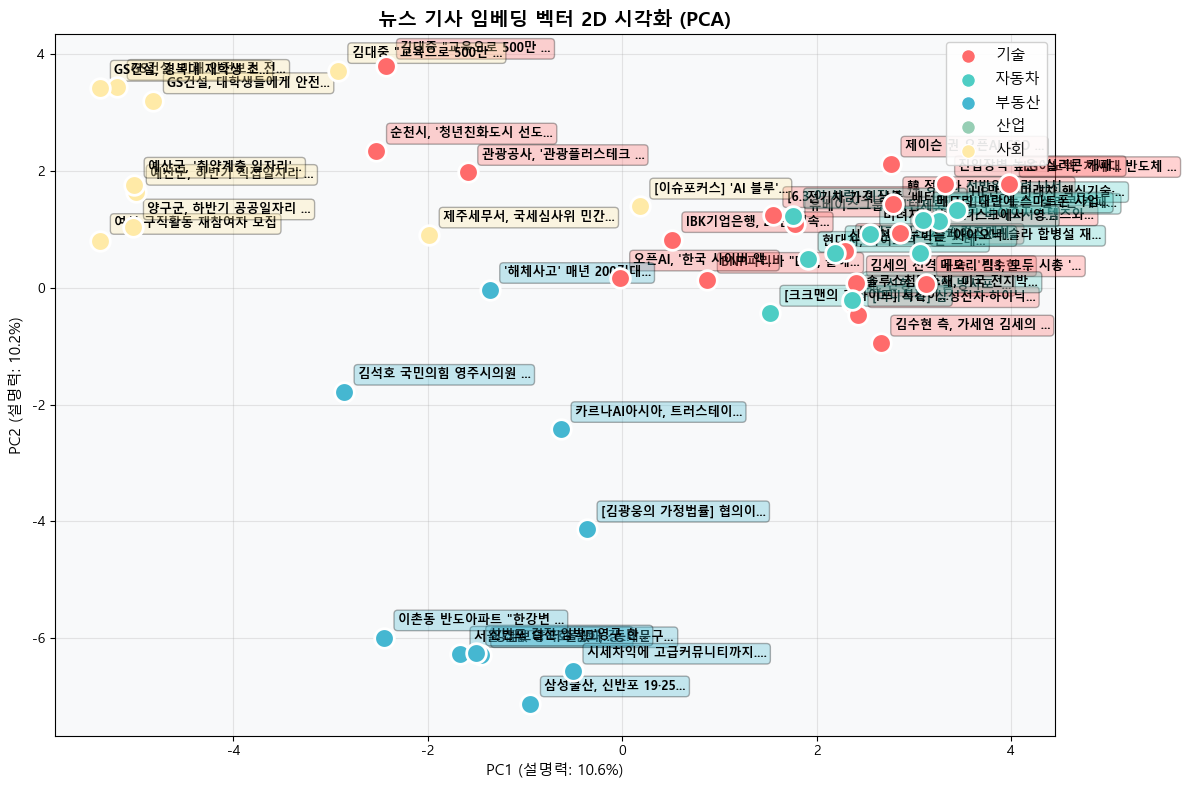


의미적으로 유사한 기사들이 가까이 위치하는 것을 확인하세요!


In [16]:
# ================================================================
# 임베딩 벡터 2D 시각화 (PCA)
# ================================================================

# PCA 란?
# - 임베딩 벡터는 수백~수천 차원 → 사람 눈으로 볼 수 없음
# - PCA 로 2차원으로 압축해서 그래프에 점으로 표시
# - 의미가 비슷한 기사들은 압축 후에도 가까이 모여 있어야 함
# - 같은 카테고리(기술/부동산 등)끼리 뭉쳐 있으면 임베딩이 잘 된 것

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

# 뉴스 기사의 임베딩 벡터와 메타데이터 전부 가져오기
all_data = collection_news.get(
    include=["embeddings", "metadatas"]
    # include : 어떤 데이터를 가져올지 지정
    # "embeddings" : 저장된 숫자 벡터
    # "metadatas"  : 카테고리, 제목 등 부가 정보
)

# 벡터 배열과 카테고리/제목 리스트로 분리
embeddings = np.array(all_data['embeddings'])   # shape: (기사수, 벡터차원수)
categories = [m['category'] for m in all_data['metadatas']]
titles     = [m['title']    for m in all_data['metadatas']]

# PCA 로 고차원 벡터를 2차원으로 압축
pca = PCA(n_components=2)          # 2개의 주성분(축)으로 압축
coords = pca.fit_transform(embeddings)
# fit_transform : 데이터 특성을 학습(fit) 후 변환(transform)
# coords shape : (기사수, 2) → 각 기사가 (x, y) 좌표로 변환됨

# 시각화
fig, ax = plt.subplots(figsize=(12, 8))

# 카테고리별 색상 지정
color_map = {
    "기술":   "#FF6B6B",
    "자동차": "#4ECDC4",
    "부동산": "#45B7D1",
    "산업":   "#96CEB4",
    "사회":   "#FFEAA7",
}

for i, (x, y) in enumerate(coords):
    # 카테고리에 맞는 색상 선택, 없으면 회색
    color = color_map.get(categories[i], "#999999")

    # 점 찍기
    ax.scatter(x, y, c=color, s=200, edgecolors='white', linewidths=2, zorder=5)

    # 제목 라벨 (15글자 초과 시 '...' 처리)
    short_title = titles[i][:15] + "..." if len(titles[i]) > 15 else titles[i]

    # annotate : 점 옆에 텍스트 라벨 추가
    ax.annotate(
        short_title,
        (x, y),
        textcoords="offset points",   # 점으로부터 (10, 10) 픽셀 떨어진 위치에 표시
        xytext=(10, 10),
        fontsize=9,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.3)
    )

# 범례 추가 (카테고리별 색상 설명)
for cat, color in color_map.items():
    ax.scatter([], [], c=color, s=100, label=cat, edgecolors='white')
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)

# 축 제목 - explained_variance_ratio_ : 각 축이 전체 정보의 몇 %를 설명하는지
ax.set_title('뉴스 기사 임베딩 벡터 2D 시각화 (PCA)', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 (설명력: {pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax.set_ylabel(f'PC2 (설명력: {pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

print("\n의미적으로 유사한 기사들이 가까이 위치하는 것을 확인하세요!")

In [17]:
# ================================================================
# STEP 6. GraphDB - Neo4j 연결 & 데이터 생성
# ================================================================

import os
from dotenv import load_dotenv
from neo4j import GraphDatabase # Neo4j 파이썬 드라이버

load_dotenv(override=True)
NEO4J_URI      = os.getenv('NEO4J_URI')       # bolt://localhost:7687
NEO4J_USER     = os.getenv('NEO4J_USER')      # neo4j
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD')  # 설정한 비밀번호
NEO4J_DATABASE = "neo4j"                      # 기본 데이터베이스 이름

# ----------------------------------------------------------------
# Neo4j 드라이버 생성 & 연결 확인
# ----------------------------------------------------------------

# GraphDatabase.driver() : Neo4j 서버에 접속하는 드라이버 객체 생성
# 드라이버 = Neo4j 서버와 통신하는 연결 담당 객체
# bolt:// 는 Neo4j 전용 통신 프로토콜 (http:// 같은 것)
driver = GraphDatabase.driver(
    NEO4J_URI,
    auth=(NEO4J_USER, NEO4J_PASSWORD)
)

# verify_connectivity() : 서버에 실제로 연결되는지 확인
driver.verify_connectivity()
# 이후 코드에서 Neo4j 사용 가능 여부를 체크할 때 쓸 플래그
neo4j_available = True

In [19]:
# ================================================================
# Cypher 쿼리 실행 함수 정의
# ================================================================
# Neo4j 에 쿼리를 날릴 때마다 아래 과정을 반복해야 함:
#   1. 세션 열기
#   2. 쿼리 실행
#   3. 결과 반환
#   4. 세션 닫기
# 이걸 매번 쓰면 번거로우니까 함수로 묶어둠

def run_cypher(query, parameters=None):
    """
    Neo4j 에 Cypher 쿼리를 실행하고 결과를 리스트로 반환
    query : 실행할 Cypher 쿼리 문자열
    parameters : 쿼리에 넣을 변수값 딕셔너리 (없으면 빈 딕셔너리)
    """
    # with : 세션을 열고 작업 후 자동으로 닫아줌
    with driver.session(database=NEO4J_DATABASE) as session:
        result = session.run(query, parameters or {})
        # record.data() : 결과 한 행을 딕셔너리로 변환
        # 전체 결과를 딕셔너리 리스트로 반환
        return [record.data() for record in result]



In [20]:
# ================================================================
# 그래프 데이터 생성
# ================================================================
# Cypher 문법 핵심 정리:
#
#   노드 생성:
#   CREATE (변수명:라벨 {속성명: '값', ...})
#   예) CREATE (cs:Person {name: '김철수', age: 28})
#       cs     = 이 쿼리 안에서만 쓰는 변수명
#       Person = 노드의 타입/카테고리 (라벨)
#       {}     = 노드에 저장할 속성들
#
#   관계 생성:
#   CREATE (a)-[:관계타입 {속성}]->(b)
#   예) CREATE (cs)-[:FRIEND {since: 2020}]->(yh)
#       ->  = 방향 (cs 가 yh 에게 FRIEND 관계)
#       [:FRIEND] = 관계의 타입
#       {since: 2020} = 관계에 붙는 속성

if neo4j_available:
    # 기존 데이터 전부 삭제(초기화)
    # MATCH (n)         : 모든 노드를 찾아서
    # DETACH DELETE n   : 연결된 관계까지 함께 삭제
    run_cypher("MATCH (n) DETACH DELETE n")
    print("기존 데이터 삭제 완료")

    # 노드 6개 + 관계 9개를 한 번에 생성하는 쿼리
    create_query = """
    CREATE (cs:Person {name: '김철수', age: 28, job: '개발자',     city: '서울'})
    CREATE (yh:Person {name: '이영희', age: 32, job: '디자이너',   city: '서울'})
    CREATE (ms:Person {name: '박민수', age: 25, job: '개발자',     city: '부산'})
    CREATE (je:Person {name: '최지은', age: 30, job: 'PM',         city: '서울'})
    CREATE (hj:Person {name: '정호진', age: 27, job: '데이터분석가', city: '대전'})
    CREATE (sj:Person {name: '한수진', age: 29, job: '개발자',     city: '서울'})

    CREATE (cs)-[:FRIEND    {since: 2020}]->(yh)
    CREATE (cs)-[:FRIEND    {since: 2021}]->(ms)
    CREATE (yh)-[:COLLEAGUE {company: '테크Corp'}]->(je)
    CREATE (je)-[:MANAGES   {since: 2022}]->(cs)
    CREATE (ms)-[:FRIEND    {since: 2023}]->(hj)
    CREATE (hj)-[:COLLEAGUE {company: '데이터Lab'}]->(sj)
    CREATE (sj)-[:FRIEND    {since: 2019}]->(cs)
    CREATE (yh)-[:FOLLOWS]->(hj)
    CREATE (je)-[:FOLLOWS]->(sj)

    RETURN count(*) as created
    """

    run_cypher(create_query)
    print("Neo4j 그래프 데이터 생성 완료")

    # 생성된 노드 확인
    # MATCH (n:Person)  : Person 라벨을 가진 노드 전부 찾기
    # RETURN n.name     : 노드의 name 속성만 반환
    result = run_cypher("""MATCH (n:Person)
                        RETURN n.name AS name, n.job As job, n.city AS city""")

    print("\n생성된 노드:") 
    for r in result:
        print(f"    {r['name']} — {r['job']}, {r['city']}")


기존 데이터 삭제 완료
Neo4j 그래프 데이터 생성 완료

생성된 노드:
    김철수 — 개발자, 서울
    이영희 — 디자이너, 서울
    박민수 — 개발자, 부산
    최지은 — PM, 서울
    정호진 — 데이터분석가, 대전
    한수진 — 개발자, 서울


In [21]:
# ================================================================
# STEP 7. Cypher 쿼리 - 패턴 매칭 / 2-hop 탐색 / 최단경로
# ================================================================

# ----------------------------------------------------------------
# 쿼리 1. 모든 FRIEND 관계 조회
# ----------------------------------------------------------------
# MATCH (a:Person)-[r:FRIEND]->(b:Person)
#   (a:Person) : Person 라벨을 가진 노드를 a 라는 변수로
#   -[r:FRIEND]-> : FRIEND 타입의 관계를 r 이라는 변수로
#   (b:Person) : 관계의 도착 노드를 b 라는 변수로
#   → a 가 b 에게 FRIEND 관계인 패턴을 전부 찾아라
#
# RETURN a.name, b.name, r.since
#   → 찾은 패턴에서 각 노드/관계의 속성값을 꺼내서 반환
#
# ORDER BY r.since
#   → since(친구가 된 연도) 오름차순으로 정렬

print("모든 FRIEND 관계 조회")
print("=" * 50)

results = run_cypher("""
                     MATCH (a:Person)-[r:FRIEND]->(b:Person)
                     RETURN a.name AS from_person, b.name AS to_person, r.since AS since
                     ORDER BY r.since""")

for r in results:
    print(f"  {r['from_person']} ──FRIEND──> {r['to_person']} (since {r['since']})")

모든 FRIEND 관계 조회
  한수진 ──FRIEND──> 김철수 (since 2019)
  김철수 ──FRIEND──> 이영희 (since 2020)
  김철수 ──FRIEND──> 박민수 (since 2021)
  박민수 ──FRIEND──> 정호진 (since 2023)


In [22]:
# ----------------------------------------------------------------
# 쿼리 2. 서울에 사는 개발자의 친구
# ----------------------------------------------------------------

# MATCH (a:Person {city: '서울', job: '개발자'})-[:FRIEND]->(b:Person)
#   {city: '서울', job: '개발자'} : 노드 속성 조건을 중괄호 안에 바로 씀
#   → city 가 서울이고 job 이 개발자인 Person 노드만 찾아라
#   → 그 노드에서 FRIEND 관계로 연결된 b 노드도 함께 찾아라
#
# WHERE 절로도 같은 조건을 쓸 수 있음:
#   MATCH (a:Person)-[:FRIEND]->(b:Person)
#   WHERE a.city = '서울' AND a.job = '개발자'

print("\n\n2. 서울에 사는 개발자의 친구")
print("=" * 50)

results = run_cypher("""
    MATCH (a:Person {city: '서울', job: '개발자'})-[:FRIEND]->(b:Person)
    RETURN a.name AS person, b.name AS friend, b.city AS friend_city
""")

for r in results:
    print(f"  {r['person']} → {r['friend']} ({r['friend_city']})")


# ----------------------------------------------------------------
# 쿼리 3. 2-hop 관계 탐색 (친구의 친구)
# ----------------------------------------------------------------

# MATCH (a)-[:FRIEND]->()-[:FRIEND]->(fof:Person)
#   (a)-[:FRIEND]->() : a 의 직접 친구 (이름 없는 중간 노드)
#   ()-[:FRIEND]->(fof) : 그 친구의 친구를 fof 변수로
#   → 총 2번 FRIEND 관계를 따라가는 패턴
#
# WHERE fof.name <> '김철수'
#   <> : 같지 않다 (not equal)
#   → 자기 자신이 결과에 포함되지 않도록 제외
#
# RETURN DISTINCT
#   → 중복 결과 제거 (같은 사람이 여러 경로로 나올 수 있어서)

print("\n\n3. 2-hop 관계 탐색 (친구의 친구)")
print("=" * 50)

results = run_cypher("""
    MATCH (a:Person {name: '김철수'})-[:FRIEND]->()-[:FRIEND]->(fof:Person)
    WHERE fof.name <> '김철수'
    RETURN DISTINCT fof.name AS friend_of_friend, fof.job AS job
""")

for r in results:
    print(f"  김철수의 친구의 친구: {r['friend_of_friend']} ({r['job']})")


# ----------------------------------------------------------------
# 쿼리 4. 최단 경로 탐색
# ----------------------------------------------------------------

# shortestPath((a)-[*]-(b))
#   shortestPath() : 두 노드 사이의 최단 경로를 찾는 내장 함수
#   [*]            : 관계 타입 상관없이 모든 관계를 따라감
#   -              : 방향 상관없이 양방향으로 탐색
#   → 김철수에서 정호진까지 가장 적은 관계를 거치는 경로 탐색
#
# nodes(path)
#   → 경로에 포함된 노드 목록을 반환
#
# [node IN nodes(path) | node.name]
#   → 노드 목록에서 name 속성만 뽑아서 리스트로 만들기
#   → 파이썬의 [x.name for x in nodes] 와 같은 문법
#
# length(path)
#   → 경로의 길이 (거친 관계의 수 = hop 수)

print("\n\n4. 최단 경로 탐색")
print("=" * 50)

results = run_cypher("""
    MATCH path = shortestPath(
        (a:Person {name: '김철수'})-[*]-(b:Person {name: '정호진'})
    )
    RETURN [node IN nodes(path) | node.name] AS path_nodes,
           length(path) AS hops
""")

for r in results:
    # ' → '.join(리스트) : 리스트 원소들을 ' → ' 로 연결해서 문자열로
    print(f"  경로: {' → '.join(r['path_nodes'])} ({r['hops']} hops)")



2. 서울에 사는 개발자의 친구
  김철수 → 이영희 (서울)
  김철수 → 박민수 (부산)
  한수진 → 김철수 (서울)


3. 2-hop 관계 탐색 (친구의 친구)
  김철수의 친구의 친구: 정호진 (데이터분석가)


4. 최단 경로 탐색
  경로: 김철수 → 박민수 → 정호진 (2 hops)
